In [ ]:
import os
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
from itertools import islice

from cryo_sbi import CryoEmSimulator
from cryo_sbi.inference.models import build_models
import cryo_sbi.inference.train_nle_model as train_nle_model
import cryo_sbi.inference.train_npe_model as train_npe_model
import cryo_sbi.utils.estimator_utils as est_utils
from cryo_sbi.inference.priors import get_image_priors, PriorLoader
import cryo_sbi.utils.image_utils as img_utils
from cryo_sbi.utils.visualize_models import plot_model

#### If you want to run the latent space analysis with UMAP, you need to install the following package:
You can find the installation instructions [here](https://umap-learn.readthedocs.io/en/latest/). 


In [ ]:
# If you installed umap you can import it here 
import umap

/home/zvh378/envs/cryoSBI/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Make the models 

Here we are creating a simple molecular model. 
In our model we will have four pseudo atoms arranged in a rectangle. The model differs between the sidelength we are using. The atoms are placed at the corners of the rectangle. The distance between the atoms is the same for all atoms.
The goal is then to simulate cryo-EM images with these models and infer the distance between the two atoms from the images.

The first step is to create the models. We start by crating an array with the side length `side_length` between the atoms. We will use this array to create the models.
The models are created by placing pseudo atoms at the corners of the rectangle.

The models are saved into teh file `models.pt`.



In [ ]:
side_lengths = torch.linspace(0, 50, 100)

models = []
for side_length in side_lengths:
    model = [
        [side_length, -side_length, side_length, -side_length],
        [side_length, side_length, -side_length, -side_length],
        [0.0, 0.0, 0.0, 0.0],
    ]
    models.append(model)
models = torch.tensor(models)

In [ ]:
models.shape

torch.Size([100, 3, 4])

##### Visualize the models

To visulaize the model in the x-y plane, as we do not have a z-dimension in our model.

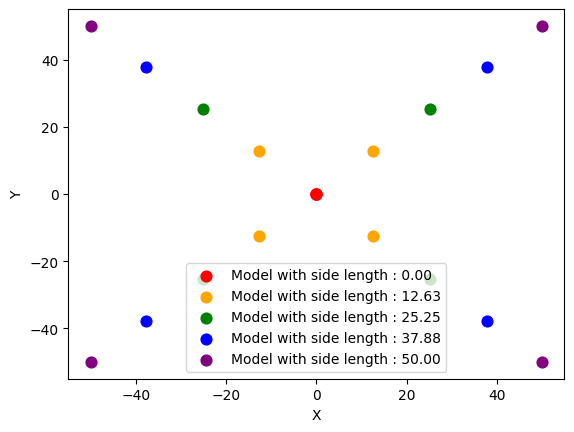

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()
for i, c in zip([0, 25, 50, 75, 99], ["red", "orange", "green", "blue", "purple"]):
    ax.scatter(
        models[i, 0, 0],
        models[i, 1, 0],
        s=60,
        color=c,
        label=f"Model with side length : {side_lengths[i]:.2f}",
    )
    ax.scatter(models[i, 0, 1], models[i, 1, 1], s=60, color=c)
    ax.scatter(models[i, 0, 2], models[i, 1, 2], s=60, color=c)
    ax.scatter(models[i, 0, 3], models[i, 1, 3], s=60, color=c)

ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.legend()



In [ ]:
# substract of center of mass
for i in range(100):
    models[i] = models[i] - models[i].mean(dim=1, keepdim=True)

torch.save(models, "models.pt")

In [ ]:
models.shape

torch.Size([100, 3, 4])

### Run first simulation

We will now simulate the cryo-EM images with our generated models.
The simulation is done by the class `CryoEmSimulator`. And the simulation is run by the function `simulate` function.
The class `CryoEmSimulator` takes as input a config file with the simulation parameters. The config file used here is `simulation_parameters.json`.

The following parameters are used in the simulation:

```
simulation_parameters.json

{
    "N_PIXELS": 64,             --> size of the image
    "PIXEL_SIZE": 2.0,          --> pixel size in angstroms
    "SIGMA": [2.0, 2.0],        --> standard deviation of the gaussian
    "MODEL_FILE": "models.pt",  --> file which contains the models
    "SHIFT": 0.0,               --> shift of model center 
    "DEFOCUS": [2.0, 2.0],      --> defocus range for the simulation
    "SNR": [0.01, 0.5],         --> signal to noise ratio  for the simulation
    "AMP": 0.1,                 --> amplitude for the ctf 
    "B_FACTOR": [1.0, 1.0]      --> b factor for the ctf
} 
```

In [ ]:
simulator = CryoEmSimulator(
    "simulation_parameters.json"
)  # creating simulator with simulation parameters

In [ ]:
images, parameters = simulator.simulate(
    num_sim=5000, return_parameters=True
)  # simulating images and save parameters

In [10]:
side_length = parameters[0]  # extracting side_length from parameters
snr = parameters[-1]  # extracting snr from parameters

#### Visualize the simulated images

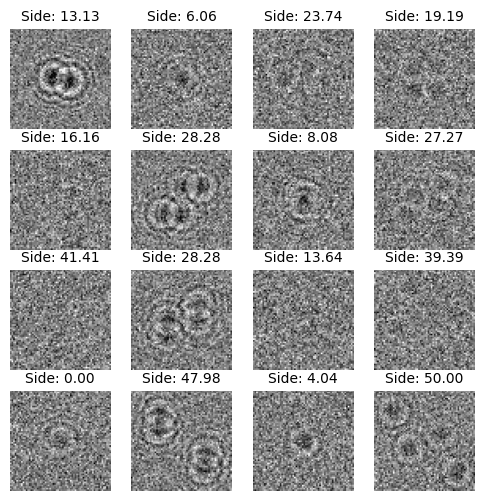

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(images[idx], vmin=-3, vmax=3, cmap="gray")
    ax.set_title(
        f"Side: {side_lengths[side_length[idx].round().long()].item():.2f}", fontsize=10
    )
    ax.axis("off")

In [12]:
images.shape

torch.Size([5000, 64, 64])

### Train cryoSBI posterior

We will now train the cryoSBI posterior to infer the distance between the atoms from the simulated images.
The training is done with the function `npe_train_no_saving` which simulates images and simultaneously trains the posterior.
The function takes as input the config file `training_parameters.json` which contains the training and neural network parameters.
The function also takes as input the config file `simulation_parameters.json` which contains the simulation parameters used to simulate the images.


```
training_parameters.json
```

```
{
    "EMBEDDING": "ConvEncoder_Tutorial",    --> embedding network for the images
    "OUT_DIM": 128,                         --> dimension of the embedding
    "NUM_TRANSFORM": 5,                     --> number of transformations
    "NUM_HIDDEN_FLOW": 5,                   --> number of hidden layers in the flow
    "HIDDEN_DIM_FLOW": 128,                 --> dimension of the hidden layers in the flow
    "MODEL": "NSF",                         --> type of flow
    "LEARNING_RATE": 0.0003,                --> learning rate
    "CLIP_GRADIENT": 5.0,                   --> gradient clipping
    "THETA_SHIFT": 50,                      --> shift of the model center
    "THETA_SCALE": 50,                      --> scale of the model
    "BATCH_SIZE": 32                        --> batch size
}
```


In [13]:
train_nle_model.nle_train_no_saving(
    "simulation_parameters.json",
    "training_parameters_nle.json",
    150,
    "tutorial_estimator.pt",  # name of the estimator file
    "tutorial.loss",  # name of the loss file
    n_workers=4,  # number of workers for data loading
    device="cuda",  # device to use for training and simulation
    saving_frequency=100,  # frequency of saving the model
    simulation_batch_size=160,  # batch size for simulation
)

NLEWithEmbedding(
  (nle): NPE(
    (flow): NSF(
      (transform): LazyComposedTransform(
        (0-2): 3 x ElementWiseTransform(
          (base): MonotonicRQSTransform(bins=8)
          (hyper): MLP(
            (0): Linear(in_features=128, out_features=128, bias=True)
            (1): LeakyReLU(negative_slope=0.1)
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): LeakyReLU(negative_slope=0.1)
            (4): Linear(in_features=128, out_features=128, bias=True)
            (5): LeakyReLU(negative_slope=0.1)
            (6): Linear(in_features=128, out_features=128, bias=True)
            (7): LeakyReLU(negative_slope=0.1)
            (8): Linear(in_features=128, out_features=64, bias=True)
            (9): LeakyReLU(negative_slope=0.1)
            (10): Linear(in_features=64, out_features=23, bias=True)
          )
        )
      )
      (base): UnconditionalDistribution(DiagNormal(loc: tensor([0.], device='cuda:0'), scale: tensor([1.], device

  0%|          | 0/150 [00:00<?, ?epoch/s]

x torch.Size([32, 4, 3])
theta torch.Size([32, 4096])
pos torch.Size([32, 4096])


  0%|          | 0/150 [00:00<?, ?epoch/s]


RuntimeError: cdist only supports at least 2D tensors, X1 got: 1D

##### Visualize the loss after training

Text(0, 0.5, 'Loss')

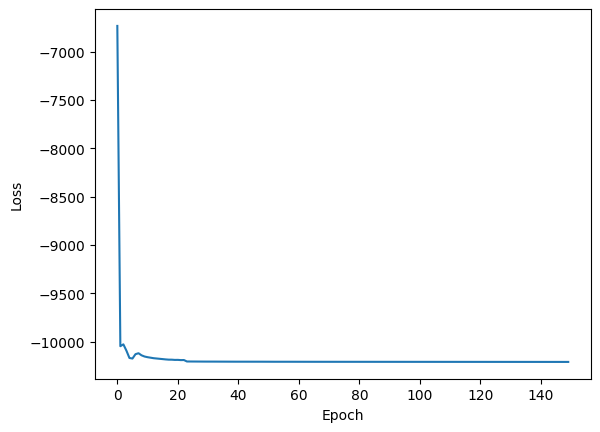

In [24]:
plt.plot(torch.load("tutorial.loss"))
plt.xlabel("Epoch")
plt.ylabel("Loss")
#plt.xlim(0,10)

### Evaluate the posterior on our simulated images

We will now evaluate the trained posterior on our simulated images.
For each simulated image we will infer the distance between the atoms and compare it to the true distance, by sampling from the posterior.

In [11]:
likelihood = est_utils.load_estimator(
    "training_parameters_nle.json",
    build_models.build_nle_flow_model,
    "tutorial_estimator.pt",
    device="cuda",
)

In [12]:
samples = est_utils.sample_posterior(
    estimator=likelihood,
    images=images,
    num_samples=15000,
    batch_size=1000,
    device="cuda",
)

torch.Size([1000, 64, 64])
torch.Size([1000, 64, 64])
torch.Size([1000, 64, 64])
torch.Size([1000, 64, 64])
torch.Size([1000, 64, 64])


In [16]:
samples

tensor([[-0.9793, -0.9963, -0.9974,  ..., -0.9594, -0.9954, -0.9858],
        [-1.0034, -0.9959, -0.9823,  ..., -0.9871, -1.0396, -1.0089],
        [-0.9957, -0.9976, -0.9657,  ..., -0.9995, -0.9596, -0.9780],
        ...,
        [-1.0032, -1.0113, -1.0073,  ..., -0.9846, -0.9957, -0.9871],
        [-0.9918, -0.9877, -0.9952,  ..., -1.0260, -0.9929, -1.0331],
        [-1.0114, -1.0110, -0.9996,  ..., -1.0128, -0.9701, -1.0047]])

In [11]:
samples[0]

tensor([-1.0289, -0.9815, -0.9868,  ..., -1.0030, -0.9968, -0.9827])

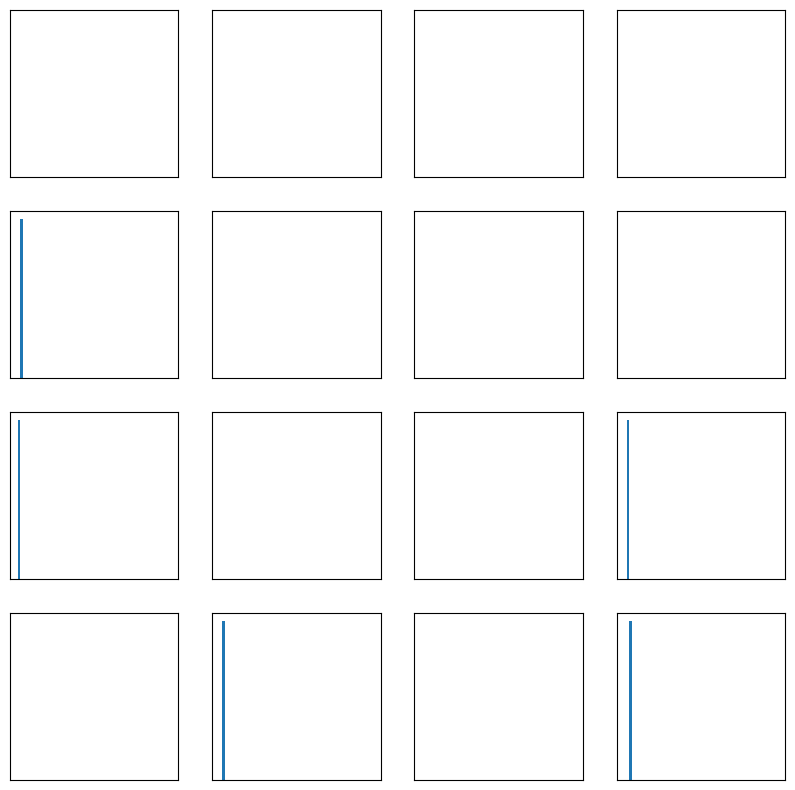

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for idx, ax in enumerate(axes.flatten()):
    ax.hist(samples[:, idx].flatten(), bins=np.linspace(0, simulator.max_index, 60))
    #ax.axvline(side_length[idx], ymax=1, ymin=0, color="red")
    ax.set_yticks([])
    ax.set_xticks([])

### Plot latent space

In [11]:
latent_representations = est_utils.compute_latent_repr(
    estimator=likelihood,
    images=images,
    batch_size=1000,
    device="cuda",
)

In [12]:
reducer = umap.UMAP(metric="euclidean", n_components=2, n_neighbors=50)
latent_vecs_transformed = reducer.fit_transform(latent_representations.numpy())

Text(0, 0.5, 'UMAP 2')

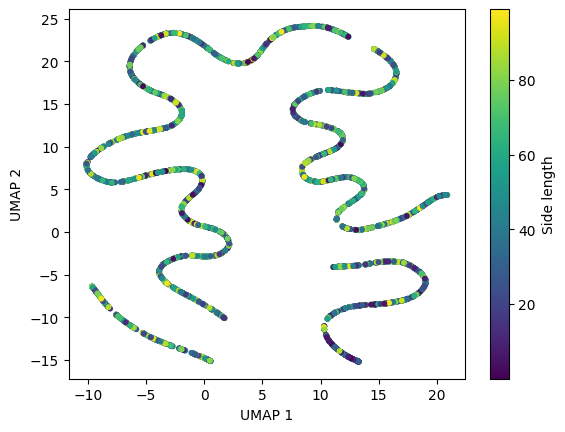

In [13]:
plt.scatter(
    latent_vecs_transformed[:, 0],
    latent_vecs_transformed[:, 1],
    c=side_length,
    cmap="viridis",
    s=10,
)
plt.colorbar(label="Side length")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

Text(0, 0.5, 'UMAP 2')

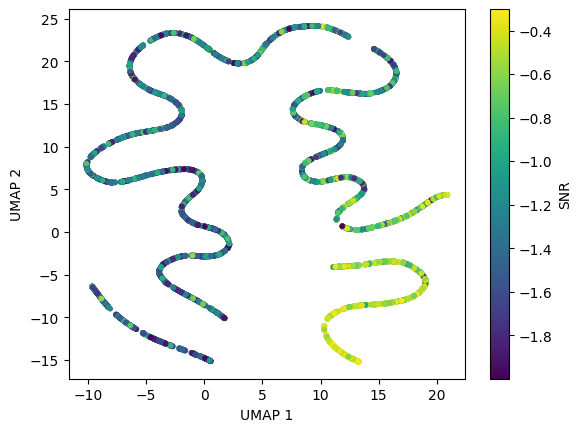

In [14]:
plt.scatter(
    latent_vecs_transformed[:, 0],
    latent_vecs_transformed[:, 1],
    c=snr,
    cmap="viridis",
    s=10,
)
plt.colorbar(label="SNR")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

In [17]:
likelihood.flow

<bound method NLEWithEmbedding.flow of NLEWithEmbedding(
  (nle): NPE(
    (flow): NSF(
      (transform): LazyComposedTransform(
        (0-2): 3 x ElementWiseTransform(
          (base): MonotonicRQSTransform(bins=8)
          (hyper): MLP(
            (0): Linear(in_features=128, out_features=128, bias=True)
            (1): LeakyReLU(negative_slope=0.1)
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): LeakyReLU(negative_slope=0.1)
            (4): Linear(in_features=128, out_features=128, bias=True)
            (5): LeakyReLU(negative_slope=0.1)
            (6): Linear(in_features=128, out_features=128, bias=True)
            (7): LeakyReLU(negative_slope=0.1)
            (8): Linear(in_features=128, out_features=64, bias=True)
            (9): LeakyReLU(negative_slope=0.1)
            (10): Linear(in_features=64, out_features=23, bias=True)
          )
        )
      )
      (base): UnconditionalDistribution(DiagNormal(loc: tensor([0.], devic

In [118]:
indices_prior = torch.randint(0, len(models), (100,))
theta_prior = models[indices_prior]

In [ ]:
def sample_likelihood(
    likelihood_model: torch.nn.Module,
    thetas: torch.Tensor,
    num_samples: int,
    batch_size: int = 100,
    device: str = "cpu",
    H: int = 64,
    W: int = 64,
) -> torch.Tensor:
    """
    Samples synthetic images from a likelihood flow conditioned on θ.

    Args:
        likelihood_model (torch.nn.Module): Conditional likelihood flow.
        thetas (torch.Tensor): Parameter vectors θ, shape [N, ...].
        num_samples (int): Number of images per θ.
        batch_size (int): Batch size for processing θ.
        device (str): Device to run on.
        H, W (int): Output image size.

    Returns:
        torch.Tensor: Synthetic images, shape [N, num_samples, H, W]
    """
    all_images = []

    # theta dimensions [num_eval, num_images, 1]
    if theta.ndim == 3:
        num_eval = theta.shape[0]
        num_images = images.shape[0]
        assert thetas.shape == torch.Size([num_eval, num_images, 1])

    elif thetas.ndim == 2:
        raise IndexError("theta must have 3 dimensions [num_eval, num_images, 1]")

    elif thetas.ndim == 1:
        thetas = thetas.reshape(-1, 1, 1).repeat(1, batch_size, 1)

    with torch.no_grad():
        for theta in thetas:
            flow_instance = likelihood_model.flow(theta.to(device))

                # sample `num_samples` images for this θ
                x_sample = flow_instance.sample((num_samples,))  # [num_samples, flow_dim]

                # reshape if needed
               # if x_sample.numel() == num_samples * H * W:
               #     x_sample = x_sample.view(num_samples, H, W)
               # else:
                    # if flow outputs latent, you may need a decoder here
               #     raise ValueError(
               #         f"Flow output size {x_sample.shape} does not match H*W={H*W}"
               #     )

                batch_images.append(x_sample)

            all_images.append(torch.stack(batch_images, dim=0))

    return torch.cat(all_images, dim=0)  # [N, num_samples, H, W]


In [ ]:
@torch.no_grad()
def sample_likelihood(
    estimator: torch.nn.Module,
    thetas: torch.Tensor,
    num_samples: int,
    batch_size: int = 100,
    device: str = "cpu",
) -> torch.Tensor:
    """
    Samples from the posterior distribution

    Args:
        estimator (torch.nn.Module): The posterior to use for sampling.
        images (torch.Tensor): The images used to condition the posterior.
        num_samples (int): The number of samples to draw
        batch_size (int, optional): The batch size for sampling. Defaults to 100.
        device (str, optional): The device to use. Defaults to "cpu".

    Returns:
        torch.Tensor: The posterior samples
    """

    image_samples = []

    for theta in thetas:
        flow_instance = estimator.flow(theta.to(device)).sample(1,)

    #if images.shape[0] > batch_size and batch_size > 0:
    #    images = torch.split(images, split_size_or_sections=batch_size, dim=0)
    #else:
    #    batch_size = images.shape[0]
    #    images = [images]

    #for image_batch in images:
    #    samples = estimator.sample(
    #        image_batch.to(device, non_blocking=True), shape=(num_samples,)
    #    ).cpu()
    #    theta_samples.append(samples.reshape(-1, image_batch.shape[0]))

    #return torch.cat(theta_samples, dim=1)

torch.Size([100, 3, 4])

In [133]:
all_images = sample_likelihood(likelihood_model = likelihood,thetas = theta_prior,num_samples=5000,batch_size=1000)

In [35]:
indices_prior = torch.randint(0, len(models), (32,))
theta_prior = models[indices_prior]
theta_prior = theta_prior.permute(0, 2, 1)
theta_prior.shape

torch.Size([32, 4, 3])

In [18]:
device = 'cuda'

In [20]:
#for theta in samples:
#    print(theta.shape)
flow_instance = likelihood.flow(samples.to(device)).sample()


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x15000 and 128x128)

In [ ]:
dists = torch.stack([torch.cdist(p, p) for p in positions])
        print('dists',dists.shape)
        #  Mean distance to other nodes
        h = dists.mean(dim=-1)  # [B, N]
        print('h',h.shape)
        #  Prepare for node-level MLP: last dim = 1
        h = h.unsqueeze(-1)     # [B, N, 1]
        print('h',h.shape)
        #  Node-level MLP applied per node (node level representation)
        h = self.node_mlp(h)    # [B, N, 128]
        print('h',h.shape)
        #  Global pooling over nodes
        h = h.mean(dim=1)       # [B, 128]
        print('h',h.shape)
        #  Global MLP to produce final embedding
        out = self.global_mlp(h)  # [B, output_dim]
        print('out',out.shape)